<a href="https://colab.research.google.com/github/Ashwin1934/PortfolioAnalysisMonorepo/blob/main/Model_08_20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas
import nltk
from sklearn.model_selection import train_test_split
import numpy
from time import perf_counter

Check that GPU is available in colab. Change runtime in between and observe the difference.

In [22]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))
if torch.cuda.is_available():
  print(f"Number of GPUs: {torch.cuda.device_count()}")
  for i in range(torch.cuda.device_count()):
      print(f"\nGPU {i}:")
      print(f"  Name: {torch.cuda.get_device_name(i)}")
      print(f"  Total Memory: {torch.cuda.get_device_properties(i).total_memory / 1e9:.2f} GB")
      print(f"  MultiProcessor Count: {torch.cuda.get_device_properties(i).multi_processor_count}")
      print(f"  CUDA Capability: {torch.cuda.get_device_properties(i).major}.{torch.cuda.get_device_properties(i).minor}")

True
Tesla T4
Number of GPUs: 1

GPU 0:
  Name: Tesla T4
  Total Memory: 15.83 GB
  MultiProcessor Count: 40
  CUDA Capability: 7.5


In Google Colab, pytorch automatically uses the T4 GPU specified in the runtime. The below code will come in handy when training the model on a bare metal node. We can specify the GPU and move the model/data to the GPU. Pytorch will then automatically execute operations on the GPU.

In [23]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [24]:
df = pandas.read_csv('/content/all-data.csv', encoding='ISO-8859-1', header=None, names=["Sentiment", "Headline"])
df.head()

,Sentiment,Headline
0,neutral,"According to Gran , the company has no plans t..."
1,neutral,Technopolis plans to develop in stages an area...
2,negative,The international electronic industry company ...
3,positive,With the new production plant the company woul...
4,positive,According to the company 's updated strategy f...


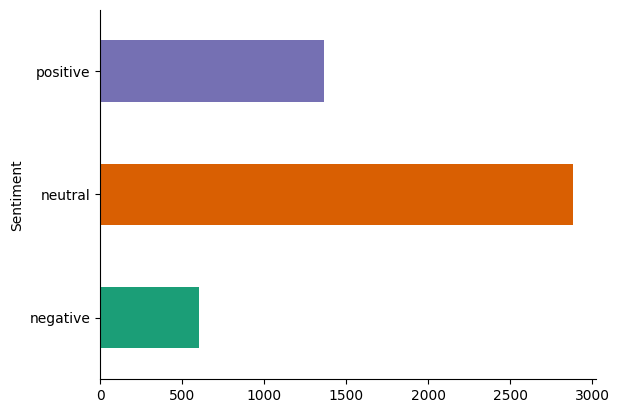

In [25]:
from matplotlib import pyplot as plt
import seaborn as sns
df.groupby('Sentiment').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

In [26]:
#lowercase
df['Headline'] = df['Headline'].str.lower()
df.info()

def remove_whitespaces(document):
  return " ".join(document.split())
df['Headline'] = df['Headline'].apply(remove_whitespaces)
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4846 entries, 0 to 4845
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Sentiment  4846 non-null   object
 1   Headline   4846 non-null   object
dtypes: object(2)
memory usage: 75.8+ KB


,Sentiment,Headline
0,neutral,"according to gran , the company has no plans t..."
1,neutral,technopolis plans to develop in stages an area...
2,negative,the international electronic industry company ...
3,positive,with the new production plant the company woul...
4,positive,according to the company 's updated strategy f...


In [27]:
nltk.download('punkt_tab')
from nltk import word_tokenize
df['Headline'] = df['Headline'].apply(lambda headline: word_tokenize(headline))

def categorize_sentiment(sentiment):
  if sentiment == 'positive':
    return 0
  elif sentiment == 'neutral':
    return 1
  elif sentiment == 'negative':
    return 2
  return 1

df['Label'] = df['Sentiment'].apply(lambda sentiment: categorize_sentiment(sentiment))
df.head()

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


,Sentiment,Headline,Label
0,neutral,"[according, to, gran, ,, the, company, has, no...",1
1,neutral,"[technopolis, plans, to, develop, in, stages, ...",1
2,negative,"[the, international, electronic, industry, com...",2
3,positive,"[with, the, new, production, plant, the, compa...",0
4,positive,"[according, to, the, company, 's, updated, str...",0


In [28]:
#remove stopwords
nltk.download('stopwords')
from nltk.corpus import stopwords
english_stopwords = stopwords.words('english')

def remove_stopwords(document):
  result = []
  for token in document:
    if token not in english_stopwords:
      result.append(token)
  return result
df['Headline'] = df['Headline'].apply(remove_stopwords)
df.head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,Sentiment,Headline,Label
0,neutral,"[according, gran, ,, company, plans, move, pro...",1
1,neutral,"[technopolis, plans, develop, stages, area, le...",1
2,negative,"[international, electronic, industry, company,...",2
3,positive,"[new, production, plant, company, would, incre...",0
4,positive,"[according, company, 's, updated, strategy, ye...",0


Now build the vocabulary (represents the feature space), create a wordToIdx dictionary so we can use it in our embeddings etc. Note we haven't used pretrained embeddings like glove here

In [29]:
from collections import Counter
vocabulary = set()
for headline in df['Headline']:
  for word in headline:
    vocabulary.add(word)

vocab = Counter(vocabulary)
vocab = sorted(vocab, key=vocab.get, reverse=True)
vocab_size = len(vocab)

word2idx = {word: index for index, word in enumerate(vocab)} #create a mreverse mapping

def create_index_representation_for_headline(headline):
  return [word2idx[word] for word in headline]

df['Headline Indices'] = df['Headline'].apply(create_index_representation_for_headline)
df.head()

,Sentiment,Headline,Label,Headline Indices
0,neutral,"[according, gran, ,, company, plans, move, pro...",1,"[3162, 1631, 10415, 2421, 6717, 10699, 7927, 4..."
1,neutral,"[technopolis, plans, develop, stages, area, le...",1,"[3847, 6717, 10077, 3193, 6481, 5343, 6174, 92..."
2,negative,"[international, electronic, industry, company,...",2,"[10900, 1532, 5034, 2421, 3142, 6818, 473, 242..."
3,positive,"[new, production, plant, company, would, incre...",0,"[2039, 7927, 8711, 2421, 10260, 5771, 10725, 1..."
4,positive,"[according, company, 's, updated, strategy, ye...",0,"[3162, 2421, 378, 11480, 6220, 8256, 8866, 104..."


Split the dataset into training and test groups

In [30]:
X_train, X_test, Y_train, Y_test = train_test_split(df['Headline Indices'], df['Label'], test_size=0.2)

X_train = numpy.array(X_train)
X_test = numpy.array(X_test)
y_train = numpy.array(Y_train)
y_test = numpy.array(Y_test)

In [31]:
print(len(X_train[0]))
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)
print(X_train[0])
print(word2idx["beat"])
print(len(X_train[0]), len(X_train[200]))

17
(3876,) (3876,)
(970,) (970,)
[1043, 7076, 3591, 9523, 3591, 2003, 4159, 10902, 1043, 3626, 2421, 10578, 9685, 3848, 6798, 6828, 1623]
1067
17 40


Define the model. Using LSTM to encode the headline. Then piping in the last hidden state as the input to a feed forward neural network and performing classification.

In [32]:
class EncoderDecoder(nn.Module):

  def __init__(self, embedding_dim, vocab_size, num_classes) -> None:
    super(EncoderDecoder, self).__init__()

    self.embedding = nn.Embedding(vocab_size, embedding_dim)
    self.lstm = nn.LSTM(embedding_dim, 50, batch_first=True)

    self.linear = nn.Linear(50, num_classes)
    #self.logsoftmax = nn.LogSoftmax(dim=-1)

  def forward(self, headline):
    embedding = self.embedding(headline)      # [seq_len, embedding_dim]
    embedding = embedding.unsqueeze(0)        # [batch=1, seq_len, embedding_dim]
    #print("embedding shape", embedding.shape)

    lstm_out, (hidden, cell) = self.lstm(embedding)
    #print("lstm out shape", lstm_out.shape)  # [batch, seq_len, hidden_dim]

    # last hidden state from the last word, i.e. a representation of the full sentence
    last_hidden = hidden[-1]       # [batch, hidden_dim]
    #print("hidden shape", last_hidden.shape)

    logits = self.linear(last_hidden)          # [batch, num_classes]
    log_probs = F.log_softmax(logits, dim=-1)  # normalize over classes

    return log_probs.squeeze(0) # [num_classes] for single example


Noticed that torch.cuda.memory_allocated() was returning 0.0 MB in each epoch. This means the GPU is not being used for operations. We need to explicitly move the data/model over to the GPU. In the two subsequent cells we move the model to cuda and the training data to cuda.

In [33]:
num_classes=3
model = EncoderDecoder(embedding_dim=100, vocab_size=vocab_size, num_classes=num_classes).to(device)
print(model)

EncoderDecoder(
  (embedding): Embedding(11576, 100)
  (lstm): LSTM(100, 50, batch_first=True)
  (linear): Linear(in_features=50, out_features=3, bias=True)
)


In [34]:
X_train_tensors = []
for headline_indicies in X_train:
  X_train_tensors.append(torch.tensor(headline_indicies, dtype=torch.long, device=device))
sample_row_output = model.forward(torch.tensor(X_train_tensors[0]))

/tmp/ipython-input-3959741638.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  sample_row_output = model.forward(torch.tensor(X_train_tensors[0]))


In [35]:
print(len(X_train[0]))
print(sample_row_output[0].shape)
print(sample_row_output)
#print(sample_row_output[1][0].shape) used to log lstm output
# print(sample_row_output[1][1].shape)

17
torch.Size([])
tensor([-0.7737, -1.4129, -1.2199], device='cuda:0',
       grad_fn=<SqueezeBackward1>)


In [36]:
# model training
from torch import optim
epochs = 8

#Define Loss Function and Optimizer
optimizer = optim.Adam(model.parameters(), lr = 0.01)
criterion = nn.NLLLoss() # Negative Log Likelihood Loss for log_softmax output

start = perf_counter()
for x in range(epochs):

  total_loss = 0.0
  num_correct = 0

  for i in range(len(X_train_tensors)):

    headline_tensor = X_train_tensors[i]
    label_tensor = torch.tensor(y_train[i], dtype=torch.long).to(device)

    optimizer.zero_grad()

    class_log_probs = model.forward(headline_tensor)
    loss = criterion(class_log_probs.unsqueeze(0), label_tensor.unsqueeze(0))

    loss.backward()
    optimizer.step()

    total_loss += loss.item()

    predicted_label = torch.argmax(class_log_probs)
    if predicted_label == label_tensor:
      num_correct += 1

  epoch_loss = total_loss / len(X_train_tensors)
  accuracy = num_correct / len(X_train_tensors)

  print('------------------------')
  print(f'Finished epoch {x}, total loss equals {total_loss}')
  print(f'Epoch {x+1}/{epochs}, Loss: {epoch_loss:.4f}, Training Accuracy: {accuracy:.4f}')
  print(f"Allocated Memory: {torch.cuda.memory_allocated() / 1e6:.2f} MB")
  print(f"Cached Memory: {torch.cuda.memory_reserved() / 1e6:.2f} MB")
end = perf_counter()


------------------------
Finished epoch 0, total loss equals 3560.448026109487
Epoch 1/8, Loss: 0.9186, Training Accuracy: 0.5913
Allocated Memory: 69.13 MB
Cached Memory: 92.27 MB
------------------------
Finished epoch 1, total loss equals 3262.6612665879074
Epoch 2/8, Loss: 0.8418, Training Accuracy: 0.6318
Allocated Memory: 69.13 MB
Cached Memory: 92.27 MB
------------------------
Finished epoch 2, total loss equals 3013.3936444918945
Epoch 3/8, Loss: 0.7774, Training Accuracy: 0.6610
Allocated Memory: 69.13 MB
Cached Memory: 92.27 MB
------------------------
Finished epoch 3, total loss equals 2853.776861777529
Epoch 4/8, Loss: 0.7363, Training Accuracy: 0.6858
Allocated Memory: 69.13 MB
Cached Memory: 92.27 MB
------------------------
Finished epoch 4, total loss equals 2748.889201884529
Epoch 5/8, Loss: 0.7092, Training Accuracy: 0.6987
Allocated Memory: 69.13 MB
Cached Memory: 92.27 MB
------------------------
Finished epoch 5, total loss equals 2568.0279547180908
Epoch 6/8, Lo

In [52]:
# Instantiate the Bidirectional model with pre-trained embeddings
embedding_dim = 100 # This should match the dimension of your GloVe embeddings
num_classes = 3
hidden_dim = 50 # You can experiment with this hyperparameter

model_bidirectional_glove = BidirectionalEncoderDecoder(embedding_dim=embedding_dim,
                                                        vocab_size=vocab_size,
                                                        num_classes=num_classes,
                                                        hidden_dim=hidden_dim,
                                                        embedding_matrix=embedding_matrix_tensor).to(device)

# Define Loss Function and Optimizer
criterion = nn.NLLLoss()
# You can experiment with different learning rates
optimizer_bidirectional_glove = optim.Adam(model_bidirectional_glove.parameters(), lr=0.001)

epochs = 8 # You can experiment with the number of epochs
start_time = perf_counter()

for epoch in range(epochs):
    total_loss = 0.0
    num_correct = 0

    # Set the model to training mode
    model_bidirectional_glove.train()

    for i in range(len(X_train_tensors)):
        headline_tensor = X_train_tensors[i]
        label_tensor = torch.tensor(y_train[i], dtype=torch.long).to(device)

        optimizer_bidirectional_glove.zero_grad()

        outputs = model_bidirectional_glove(headline_tensor)
        loss = criterion(outputs.unsqueeze(0), label_tensor.unsqueeze(0))

        loss.backward()
        optimizer_bidirectional_glove.step()

        total_loss += loss.item()

        predicted_label = torch.argmax(outputs)
        if predicted_label == label_tensor:
            num_correct += 1

    epoch_loss = total_loss / len(X_train_tensors)
    accuracy = num_correct / len(X_train_tensors)

    print(f'Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}, Training Accuracy: {accuracy:.4f}')
    print(f"Allocated Memory: {torch.cuda.memory_allocated() / 1e6:.2f} MB")
    print(f"Cached Memory: {torch.cuda.memory_reserved() / 1e6:.2f} MB")


end_time = perf_counter()
print(f"\nTraining Execution Time with GloVe embeddings: {end_time - start_time:.2f} seconds")

# Evaluate the bidirectional model with GloVe embeddings on the test data
model_bidirectional_glove.eval()  # Set the model to evaluation mode
num_correct_test = 0
with torch.no_grad():  # Disable gradient calculation for evaluation
    for i in range(len(X_test_tensors)):
        headline_tensor = X_test_tensors[i]
        label_tensor = torch.tensor(y_test[i], dtype=torch.long).to(device)

        outputs = model_bidirectional_glove(headline_tensor)
        predicted_label = torch.argmax(outputs)

        if predicted_label == label_tensor:
            num_correct_test += 1

test_accuracy_bidirectional_glove = num_correct_test / len(X_test_tensors)
print(f'Bidirectional Model Test Accuracy (with GloVe): {test_accuracy_bidirectional_glove:.4f}')

Epoch 1/8, Loss: 0.7866, Training Accuracy: 0.6496
Allocated Memory: 101.25 MB
Cached Memory: 150.99 MB
Epoch 2/8, Loss: 0.5879, Training Accuracy: 0.7469
Allocated Memory: 101.25 MB
Cached Memory: 150.99 MB
Epoch 3/8, Loss: 0.4441, Training Accuracy: 0.8184
Allocated Memory: 101.25 MB
Cached Memory: 150.99 MB
Epoch 4/8, Loss: 0.3204, Training Accuracy: 0.8808
Allocated Memory: 101.25 MB
Cached Memory: 150.99 MB
Epoch 5/8, Loss: 0.2156, Training Accuracy: 0.9257
Allocated Memory: 101.25 MB
Cached Memory: 150.99 MB
Epoch 6/8, Loss: 0.1522, Training Accuracy: 0.9497
Allocated Memory: 101.25 MB
Cached Memory: 150.99 MB
Epoch 7/8, Loss: 0.1120, Training Accuracy: 0.9647
Allocated Memory: 101.25 MB
Cached Memory: 150.99 MB
Epoch 8/8, Loss: 0.0750, Training Accuracy: 0.9745
Allocated Memory: 101.25 MB
Cached Memory: 150.99 MB

Training Execution Time with GloVe embeddings: 87.00 seconds
Bidirectional Model Test Accuracy (with GloVe): 0.7577


In [50]:
# Convert the embedding matrix to a PyTorch tensor
embedding_matrix_tensor = torch.tensor(embedding_matrix, dtype=torch.float32)

In [49]:
# Create an embedding matrix for your vocabulary
embedding_dim = 100
embedding_matrix = np.zeros((vocab_size, embedding_dim))
for word, i in word2idx.items():
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        # words not found in embedding index will be all-zeros.
        embedding_matrix[i] = embedding_vector

In [48]:
import numpy as np

# Load the GloVe embeddings
glove_file = 'glove.6B.100d.txt' # Using 100d embeddings as embedding_dim is 100
embeddings_index = {}
with open(glove_file, 'r', encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coefs

print(f'Found {len(embeddings_index)} word vectors.')

Found 400000 word vectors.


In [47]:
# Download GloVe embeddings
!wget http://nlp.stanford.edu/data/glove.6B.zip
!unzip -q glove.6B.zip

--2025-08-21 01:38:21--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2025-08-21 01:38:21--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2025-08-21 01:38:22--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glov

In [46]:
# Instantiate the Bidirectional model
embedding_dim = 100
num_classes = 3
# You can experiment with different hidden_dim values as part of hyperparameter tuning
hidden_dim = 50
model_bidirectional = BidirectionalEncoderDecoder(embedding_dim=embedding_dim,
                                                  vocab_size=vocab_size,
                                                  num_classes=num_classes,
                                                  hidden_dim=hidden_dim).to(device)

# Define Loss Function and Optimizer
criterion = nn.NLLLoss()
# You can experiment with different learning rates
optimizer_bidirectional = optim.Adam(model_bidirectional.parameters(), lr=0.001)

epochs = 8
start_time = perf_counter()

for epoch in range(epochs):
    total_loss = 0.0
    num_correct = 0

    # Set the model to training mode
    model_bidirectional.train()

    for i in range(len(X_train_tensors)):
        headline_tensor = X_train_tensors[i]
        label_tensor = torch.tensor(y_train[i], dtype=torch.long).to(device)

        optimizer_bidirectional.zero_grad()

        outputs = model_bidirectional(headline_tensor)
        loss = criterion(outputs.unsqueeze(0), label_tensor.unsqueeze(0))

        loss.backward()
        optimizer_bidirectional.step()

        total_loss += loss.item()

        predicted_label = torch.argmax(outputs)
        if predicted_label == label_tensor:
            num_correct += 1

    epoch_loss = total_loss / len(X_train_tensors)
    accuracy = num_correct / len(X_train_tensors)

    print(f'Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}, Training Accuracy: {accuracy:.4f}')
    print(f"Allocated Memory: {torch.cuda.memory_allocated() / 1e6:.2f} MB")
    print(f"Cached Memory: {torch.cuda.memory_reserved() / 1e6:.2f} MB")


end_time = perf_counter()
print(f"\nTraining Execution Time: {end_time - start_time:.2f} seconds")

# Evaluate the bidirectional model on the test data
model_bidirectional.eval()  # Set the model to evaluation mode
num_correct_test = 0
with torch.no_grad():  # Disable gradient calculation for evaluation
    for i in range(len(X_test_tensors)):
        headline_tensor = X_test_tensors[i]
        label_tensor = torch.tensor(y_test[i], dtype=torch.long).to(device)

        outputs = model_bidirectional(headline_tensor)
        predicted_label = torch.argmax(outputs)

        if predicted_label == label_tensor:
            num_correct_test += 1

test_accuracy_bidirectional = num_correct_test / len(X_test_tensors)
print(f'Bidirectional Model Test Accuracy: {test_accuracy_bidirectional:.4f}')

Epoch 1/8, Loss: 0.8325, Training Accuracy: 0.6373
Allocated Memory: 95.63 MB
Cached Memory: 132.12 MB
Epoch 2/8, Loss: 0.5051, Training Accuracy: 0.7949
Allocated Memory: 95.63 MB
Cached Memory: 132.12 MB
Epoch 3/8, Loss: 0.1867, Training Accuracy: 0.9358
Allocated Memory: 95.63 MB
Cached Memory: 132.12 MB
Epoch 4/8, Loss: 0.0491, Training Accuracy: 0.9866
Allocated Memory: 95.63 MB
Cached Memory: 132.12 MB
Epoch 5/8, Loss: 0.0199, Training Accuracy: 0.9961
Allocated Memory: 95.63 MB
Cached Memory: 132.12 MB
Epoch 6/8, Loss: 0.0161, Training Accuracy: 0.9961
Allocated Memory: 95.63 MB
Cached Memory: 132.12 MB
Epoch 7/8, Loss: 0.0085, Training Accuracy: 0.9979
Allocated Memory: 95.63 MB
Cached Memory: 132.12 MB
Epoch 8/8, Loss: 0.0036, Training Accuracy: 0.9995
Allocated Memory: 95.63 MB
Cached Memory: 132.12 MB

Training Execution Time: 96.08 seconds
Bidirectional Model Test Accuracy: 0.6866


In [51]:
class BidirectionalEncoderDecoder(nn.Module):

  def __init__(self, embedding_dim, vocab_size, num_classes, hidden_dim=50, embedding_matrix=None) -> None:
    super(BidirectionalEncoderDecoder, self).__init__()

    if embedding_matrix is not None:
        # Use pre-trained embeddings
        self.embedding = nn.Embedding.from_pretrained(embedding_matrix, freeze=True) # freeze=True to keep embeddings fixed
    else:
        # Learn embeddings from scratch
        self.embedding = nn.Embedding(vocab_size, embedding_dim)

    self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True, bidirectional=True)
    self.hidden_dim = hidden_dim

    self.linear = nn.Linear(hidden_dim * 2, num_classes)

  def forward(self, headline):
    embedding = self.embedding(headline)      # [seq_len, embedding_dim]
    embedding = embedding.unsqueeze(0)        # [batch=1, seq_len, embedding_dim]

    lstm_out, (hidden, cell) = self.lstm(embedding)

    last_hidden = torch.cat((hidden[-2, :, :], hidden[-1, :, :]), dim=1)       # [batch, hidden_dim * 2]

    logits = self.linear(last_hidden)          # [batch, num_classes]
    log_probs = F.log_softmax(logits, dim=-1)  # normalize over classes

    return log_probs.squeeze(0)

In [44]:
# Hyperparameter Tuning - Experimenting with Learning Rate

# Define Loss Function and Optimizer with a smaller learning rate
optimizer = optim.Adam(model.parameters(), lr = 0.001) # Reduced learning rate
criterion = nn.NLLLoss()

epochs = 8 # Keep the same number of epochs for now

start = perf_counter()
for x in range(epochs):

  total_loss = 0.0
  num_correct = 0

  for i in range(len(X_train_tensors)):

    headline_tensor = X_train_tensors[i]
    label_tensor = torch.tensor(y_train[i], dtype=torch.long).to(device)

    optimizer.zero_grad()

    class_log_probs = model.forward(headline_tensor)
    loss = criterion(class_log_probs.unsqueeze(0), label_tensor.unsqueeze(0))

    loss.backward()
    optimizer.step()

    total_loss += loss.item()

    predicted_label = torch.argmax(class_log_probs)
    if predicted_label == label_tensor:
      num_correct += 1

  epoch_loss = total_loss / len(X_train_tensors)
  accuracy = num_correct / len(X_train_tensors)

  print('------------------------')
  print(f'Finished epoch {x}, total loss equals {total_loss}')
  print(f'Epoch {x+1}/{epochs}, Loss: {epoch_loss:.4f}, Training Accuracy: {accuracy:.4f}')
  print(f"Allocated Memory: {torch.cuda.memory_allocated() / 1e6:.2f} MB")
  print(f"Cached Memory: {torch.cuda.memory_reserved() / 1e6:.2f} MB")
end = perf_counter()

print(f"\nTraining Execution Time with reduced learning rate: {end - start} seconds")

# Evaluate on test set with the updated model
model.eval()  # Set the model to evaluation mode
num_correct_test = 0
with torch.no_grad():  # Disable gradient calculation for evaluation
    for i in range(len(X_test_tensors)):
        headline_tensor = X_test_tensors[i]
        label_tensor = torch.tensor(y_test[i], dtype=torch.long).to(device)

        outputs = model.forward(headline_tensor)
        predicted_label = torch.argmax(outputs)

        if predicted_label == label_tensor:
            num_correct_test += 1

test_accuracy_tuned = num_correct_test / len(X_test_tensors)
print(f'Tuned Model Test Accuracy (lr=0.001): {test_accuracy_tuned:.4f}')

------------------------
Finished epoch 0, total loss equals 1971.151886662522
Epoch 1/8, Loss: 0.5086, Training Accuracy: 0.7944
Allocated Memory: 85.68 MB
Cached Memory: 113.25 MB
------------------------
Finished epoch 1, total loss equals 1713.464805762667
Epoch 2/8, Loss: 0.4421, Training Accuracy: 0.8238
Allocated Memory: 85.68 MB
Cached Memory: 113.25 MB
------------------------
Finished epoch 2, total loss equals 1571.6791325115246
Epoch 3/8, Loss: 0.4055, Training Accuracy: 0.8390
Allocated Memory: 85.68 MB
Cached Memory: 113.25 MB
------------------------
Finished epoch 3, total loss equals 1458.3064562055351
Epoch 4/8, Loss: 0.3762, Training Accuracy: 0.8560
Allocated Memory: 85.68 MB
Cached Memory: 113.25 MB
------------------------
Finished epoch 4, total loss equals 1348.3298777487096
Epoch 5/8, Loss: 0.3479, Training Accuracy: 0.8664
Allocated Memory: 85.68 MB
Cached Memory: 113.25 MB
------------------------
Finished epoch 5, total loss equals 1245.810477058939
Epoch 6/

Training Execution Time With GPU. For context, the initial training time of the failed attempt on the CPU was 328 seconds.. I'm sure training could be parallelized to fully utilize all the CPU cores but that's not of interest here.

In [37]:
print(f"Execution Time: {end - start} seconds")

Execution Time: 75.09430821800015 seconds


Test Accuracy

In [38]:
X_test_tensors = []
for headline_indicies in X_test:
  X_test_tensors.append(torch.tensor(headline_indicies, dtype=torch.long, device=device))

In [39]:
num_correct = 0
for i in range(len(X_test)):
  class_log_probs = model.forward(torch.tensor(X_test_tensors[i]))
  correct_label = y_test[i] # Removed - 1 as labels are already 0, 1, or 2
  predicted_label = torch.argmax(class_log_probs)

  if(correct_label == predicted_label):
    num_correct += 1

test_accuracy = num_correct / len(X_test)
print(f'Test accuracy: {test_accuracy}')

/tmp/ipython-input-674183687.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  class_log_probs = model.forward(torch.tensor(X_test_tensors[i]))


Test accuracy: 0.6030927835051546


Save the model so we can use it later..

In [40]:
lstm_ffnn = torch.save(model, 'lstm_ffnn.pt')
print('Model saved')

Model saved


In [41]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SimpleNLPModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, num_classes):
        super(SimpleNLPModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.fc = nn.Linear(embedding_dim, num_classes)

    def forward(self, x):
        embedded = self.embedding(x)
        # Simple averaging of embeddings as a sentence representation
        averaged_embedding = torch.mean(embedded, dim=0)
        output = self.fc(averaged_embedding)
        return F.log_softmax(output, dim=0)

In [42]:
# Instantiate the model
embedding_dim = 100
num_classes = 3
model_simple = SimpleNLPModel(vocab_size, embedding_dim, num_classes).to(device)

# Define Loss Function and Optimizer
criterion = nn.NLLLoss() # Negative Log Likelihood Loss for log_softmax output
optimizer_simple = optim.Adam(model_simple.parameters(), lr=0.01)

epochs = 8
start_time = perf_counter()

for epoch in range(epochs):
    total_loss = 0.0
    num_correct = 0

    for i in range(len(X_train_tensors)):
        headline_tensor = X_train_tensors[i]
        label_tensor = torch.tensor(y_train[i], dtype=torch.long).to(device)

        optimizer_simple.zero_grad()

        outputs = model_simple(headline_tensor)
        loss = criterion(outputs.unsqueeze(0), label_tensor.unsqueeze(0)) # Add batch dimension for loss function

        loss.backward()
        optimizer_simple.step()

        total_loss += loss.item()

        predicted_label = torch.argmax(outputs)
        if predicted_label == label_tensor:
            num_correct += 1

    epoch_loss = total_loss / len(X_train_tensors)
    accuracy = num_correct / len(X_train_tensors)

    print(f'Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}, Training Accuracy: {accuracy:.4f}')
    print(f"Allocated Memory: {torch.cuda.memory_allocated() / 1e6:.2f} MB")
    print(f"Cached Memory: {torch.cuda.memory_reserved() / 1e6:.2f} MB")

end_time = perf_counter()
print(f"\nTraining Execution Time: {end_time - start_time:.2f} seconds")

Epoch 1/8, Loss: 0.8005, Training Accuracy: 0.6628
Allocated Memory: 88.21 MB
Cached Memory: 113.25 MB
Epoch 2/8, Loss: 0.2102, Training Accuracy: 0.9267
Allocated Memory: 88.21 MB
Cached Memory: 113.25 MB
Epoch 3/8, Loss: 0.0918, Training Accuracy: 0.9716
Allocated Memory: 88.21 MB
Cached Memory: 113.25 MB
Epoch 4/8, Loss: 0.0686, Training Accuracy: 0.9791
Allocated Memory: 88.21 MB
Cached Memory: 113.25 MB
Epoch 5/8, Loss: 0.0647, Training Accuracy: 0.9822
Allocated Memory: 88.21 MB
Cached Memory: 113.25 MB
Epoch 6/8, Loss: 0.0525, Training Accuracy: 0.9874
Allocated Memory: 88.21 MB
Cached Memory: 113.25 MB
Epoch 7/8, Loss: 0.0363, Training Accuracy: 0.9920
Allocated Memory: 88.21 MB
Cached Memory: 113.25 MB
Epoch 8/8, Loss: 0.0350, Training Accuracy: 0.9943
Allocated Memory: 88.21 MB
Cached Memory: 113.25 MB

Training Execution Time: 48.65 seconds


In [43]:
# Evaluate the simple model on the test data
model_simple.eval()  # Set the model to evaluation mode
num_correct_test = 0
with torch.no_grad():  # Disable gradient calculation for evaluation
    for i in range(len(X_test_tensors)):
        headline_tensor = X_test_tensors[i]
        label_tensor = torch.tensor(y_test[i], dtype=torch.long).to(device)

        outputs = model_simple(headline_tensor)
        predicted_label = torch.argmax(outputs)

        if predicted_label == label_tensor:
            num_correct_test += 1

test_accuracy_simple = num_correct_test / len(X_test_tensors)
print(f'Simple Model Test Accuracy: {test_accuracy_simple:.4f}')

Simple Model Test Accuracy: 0.6938
